# Part 3 — Train models, compare them, visualize

We fit **Ridge** (simple baseline) and **Random Forest** (nonlinear) on the same Part 2 features.

**Time test:** older months train, newer months test → forecasting story.

**Spatial test:** hide whole stations → “new site” story.

**Outputs:** same CSV paths as before (`part3_model_metrics.csv`, `part3_predictions.csv`) so Part 4 still runs.

**Plots + winner:** we print **average RMSE** (time + spatial) and bar charts / scatters so the deck isn’t only tables.


### Imports + pipelines

**Pipeline** = impute → scale / one-hot → model. Keeps preprocessing consistent when we refactor to cross-validation later.

Plot style: try seaborn grid, fall back if your matplotlib is minimal.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass
print("Libraries loaded")


Libraries loaded


### Load `part2_features.csv`

If missing, run Part 2 first. 


In [2]:
ROOT = Path(".")
INPUT = ROOT / "datasets" / "part2_features.csv"
PRED_OUT = ROOT / "datasets" / "part3_predictions.csv"
METRIC_OUT = ROOT / "datasets" / "part3_model_metrics.csv"

df = pd.read_csv(INPUT, parse_dates=["date"])
print("Loaded:", INPUT, "| shape:", df.shape)
display(df.head())


Loaded: datasets/part2_features.csv | shape: (3554, 22)


,openaq_id,date,Year,Month,PM2_5,PM2_5_lag1,PM2_5_lag2,PM2_5_lag3,PM2_5_roll3_mean,PM2_5_roll3_std,PM10_lag1,NO2_lag1,O3_lag1,Temp_Mean_lag1,Wind_Speed_lag1,Precipitation_lag1,month_num,month_sin,month_cos,Green_Ratio,Latitude,Longitude
0,IT0459A,2020-07-01,2020,7,8.13,8.42,6.41,8.32,7.716667,1.132711,21.6,23.9,61.4,21.836667,9.896667,59.2,7,-0.500000,-8.660254e-01,0.813059,43.5989,13.3419
1,IT0459A,2020-08-01,2020,8,7.74,8.13,8.42,6.41,7.653333,1.086477,20.4,20.1,56.5,24.532258,9.580645,28.6,8,-0.866025,-5.000000e-01,0.813059,43.5989,13.3419
2,IT0459A,2020-09-01,2020,9,7.20,7.74,8.13,8.42,8.096667,0.341223,20.0,27.2,53.0,25.606452,10.080645,65.2,9,-1.000000,-1.836970e-16,0.813059,43.5989,13.3419
3,IT0459A,2020-10-01,2020,10,24.90,7.20,7.74,8.13,7.690000,0.467012,16.9,28.6,35.6,20.910000,9.833333,57.8,10,-0.866025,5.000000e-01,0.813059,43.5989,13.3419
4,IT0459A,2020-11-01,2020,11,18.40,24.90,7.20,7.74,13.280000,10.066837,36.4,29.3,26.0,14.580645,8.735484,52.8,11,-0.500000,8.660254e-01,0.813059,43.5989,13.3419


### Station id for grouping only

`openaq_id` is the EEA station code. We use it for spatial split but **do not** put it in `X` as a feature (that would be memorizing ids).


In [3]:
if "openaq_id" in df.columns:
    df["station_group"] = df["openaq_id"].astype(str)
else:
    df["station_group"] = "unknown"
print("Stations:", df["station_group"].nunique())


Stations: 114


### Build `X` and `y`

Target = this month’s `PM2_5`. Features = everything else except `date` and `openaq_id`.


In [4]:
target_col = "PM2_5"
ignore = {"PM2_5", "date", "openaq_id"}
model_features = [c for c in df.columns if c not in ignore]
X = df[model_features].copy()
y = df[target_col].copy()
groups = df["station_group"]
print("n_features:", len(model_features))


n_features: 20


### Time split (80% of timeline train, 20% test)

Same spirit as Part 2


In [5]:
cutoff_date = df["date"].quantile(0.8)
time_train_mask = df["date"] <= cutoff_date
time_test_mask = df["date"] > cutoff_date
X_train_t, X_test_t = X.loc[time_train_mask], X.loc[time_test_mask]
y_train_t, y_test_t = y.loc[time_train_mask], y.loc[time_test_mask]
print("Cutoff:", cutoff_date.date(), "| train/test:", len(X_train_t), len(X_test_t))


Cutoff: 2025-04-01 | train/test: 2885 669


### Spatial split (20% of stations held out)

Every row of a station stays on one side. Harder test.


In [6]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(splitter.split(X, y, groups=groups))
X_train_s, X_test_s = X.iloc[tr_idx], X.iloc[te_idx]
y_train_s, y_test_s = y.iloc[tr_idx], y.iloc[te_idx]
print("Spatial train/test rows:", len(X_train_s), len(X_test_s))


Spatial train/test rows: 2831 723


### Preprocessing

Numeric: median impute + scale. Categorical (if any): most-frequent + one-hot. Shared by Ridge and RF for a fair comparison.


In [7]:
cat_cols = [c for c in model_features if X[c].dtype == "object"]
num_cols = [c for c in model_features if c not in cat_cols]
pre = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])
print("Numeric:", len(num_cols), "| Categorical:", len(cat_cols))


Numeric: 19 | Categorical: 1


### Fit Ridge (time train)


In [8]:
ridge = Pipeline([
    ("preprocess", clone(pre)),
    ("model", Ridge(alpha=1.0, random_state=42)),
])
ridge.fit(X_train_t, y_train_t)
print("Ridge done")


Ridge done


### Fit Random Forest (time train)


In [9]:
rf = Pipeline([
    ("preprocess", clone(pre)),
    ("model", RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
])
rf.fit(X_train_t, y_train_t)
print("Random Forest done")


Random Forest done


### Metrics on **time** test


In [10]:
def reg_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

pred_ridge_t = ridge.predict(X_test_t)
pred_rf_t = rf.predict(X_test_t)
m_ridge_t = reg_metrics(y_test_t, pred_ridge_t)
m_rf_t = reg_metrics(y_test_t, pred_rf_t)
print("Ridge  time:", m_ridge_t)
print("RF     time:", m_rf_t)


Ridge  time: {'MAE': 4.805271851765079, 'RMSE': 10.496525953667906, 'R2': 0.28512617634284}
RF     time: {'MAE': 4.450732425296778, 'RMSE': 10.760361998094147, 'R2': 0.24873701575886975}


### Refit both on spatial train → evaluate spatial test


In [11]:
ridge_s = Pipeline([
    ("preprocess", clone(pre)),
    ("model", Ridge(alpha=1.0, random_state=42)),
])
rf_s = Pipeline([
    ("preprocess", clone(pre)),
    ("model", RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
])
ridge_s.fit(X_train_s, y_train_s)
rf_s.fit(X_train_s, y_train_s)
pred_ridge_s = ridge_s.predict(X_test_s)
pred_rf_s = rf_s.predict(X_test_s)
m_ridge_s = reg_metrics(y_test_s, pred_ridge_s)
m_rf_s = reg_metrics(y_test_s, pred_rf_s)
print("Ridge  spatial:", m_ridge_s)
print("RF     spatial:", m_rf_s)


Ridge  spatial: {'MAE': 4.283879270975625, 'RMSE': 6.125955278359327, 'R2': 0.45240616543326895}
RF     spatial: {'MAE': 2.879850207612337, 'RMSE': 4.696501540103068, 'R2': 0.678145308540967}


### Save metrics table


In [12]:
metrics = pd.DataFrame([
    {"split": "time", "model": "Ridge", **m_ridge_t},
    {"split": "time", "model": "RandomForest", **m_rf_t},
    {"split": "spatial", "model": "Ridge", **m_ridge_s},
    {"split": "spatial", "model": "RandomForest", **m_rf_s},
])
display(metrics)
metrics.to_csv(METRIC_OUT, index=False)
print("Saved:", METRIC_OUT)


,split,model,MAE,RMSE,R2
0,time,Ridge,4.805272,10.496526,0.285126
1,time,RandomForest,4.450732,10.760362,0.248737
2,spatial,Ridge,4.283879,6.125955,0.452406
3,spatial,RandomForest,2.879850,4.696502,0.678145


Saved: datasets/part3_model_metrics.csv


### Which model is the best?

**Primary:** lowest **average RMSE** over *time* and *spatial* rows in `metrics`.

**Tie-break:** lower average MAE, then higher average R².


### Plot — RMSE & MAE bars (lower is better)


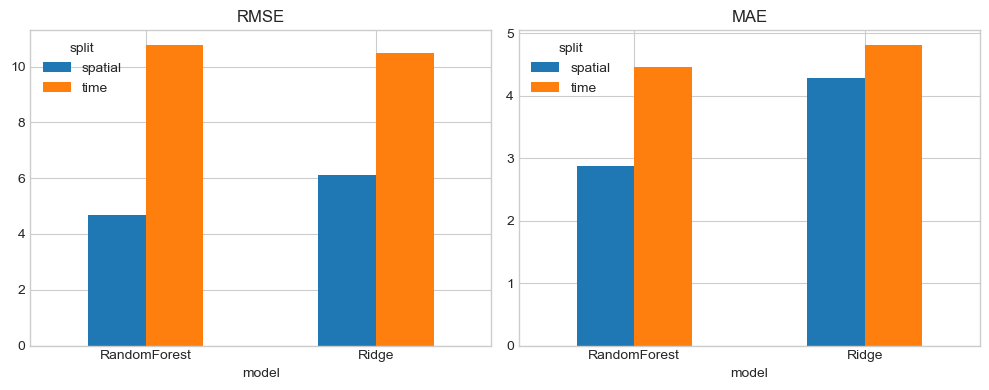

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ["RMSE", "MAE"]):
    metrics.pivot(index="model", columns="split", values=metric).plot(kind="bar", ax=ax, rot=0)
    ax.set_title(metric)
    ax.legend(title="split")
plt.tight_layout()
plt.show()


**Random Forest outperforms Ridge.**

### Plot — residuals (time test)
“Given past months at these stations, how wrong are we on future months?” - both models are not too biased.


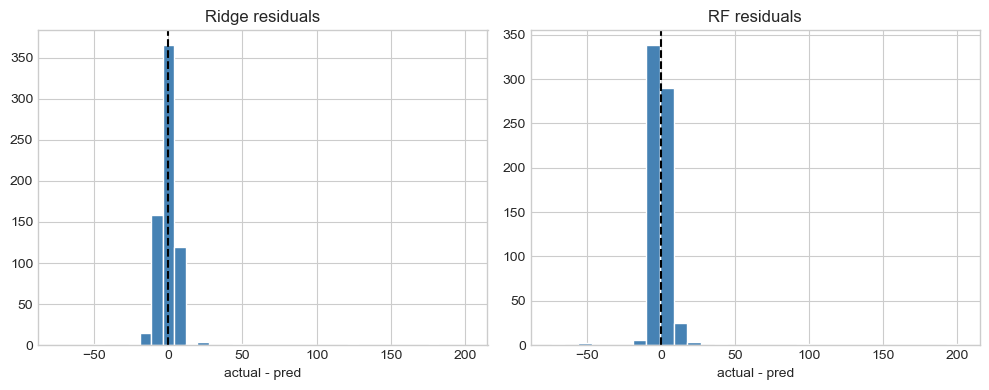

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for ax, name, pred in zip(axes, ["Ridge", "RF"], [pred_ridge_t, pred_rf_t]):
    r = y_test_t.values - pred
    ax.hist(r, bins=30, color="steelblue", edgecolor="white")
    ax.axvline(0, color="black", linestyle="--")
    ax.set_title(name + " residuals")
    ax.set_xlabel("actual - pred")
plt.tight_layout()
plt.show()


### Plot — residuals (spatial test)
“How wrong are we on stations we never trained on?”  - both models are not too biased.

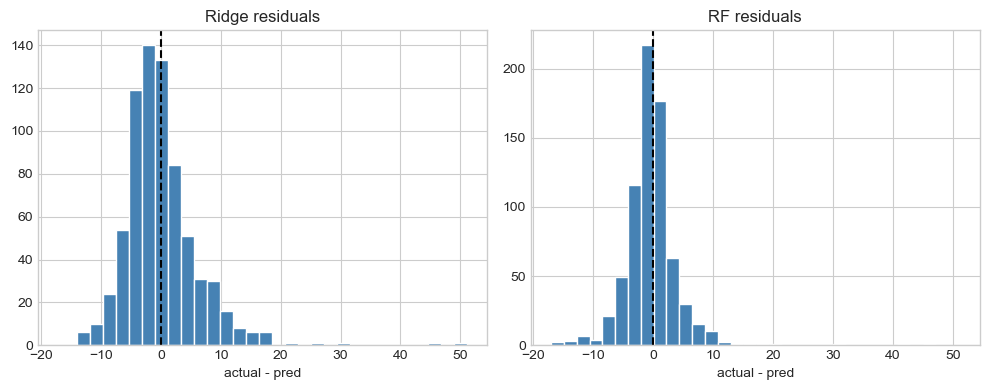

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for ax, name, pred in zip(axes, ["Ridge", "RF"], [pred_ridge_s, pred_rf_s]):
    r = y_test_s.values - pred
    ax.hist(r, bins=30, color="steelblue", edgecolor="white")
    ax.axvline(0, color="black", linestyle="--")
    ax.set_title(name + " residuals")
    ax.set_xlabel("actual - pred")
plt.tight_layout()
plt.show()

### Plot — Random Forest feature importances (top 15)


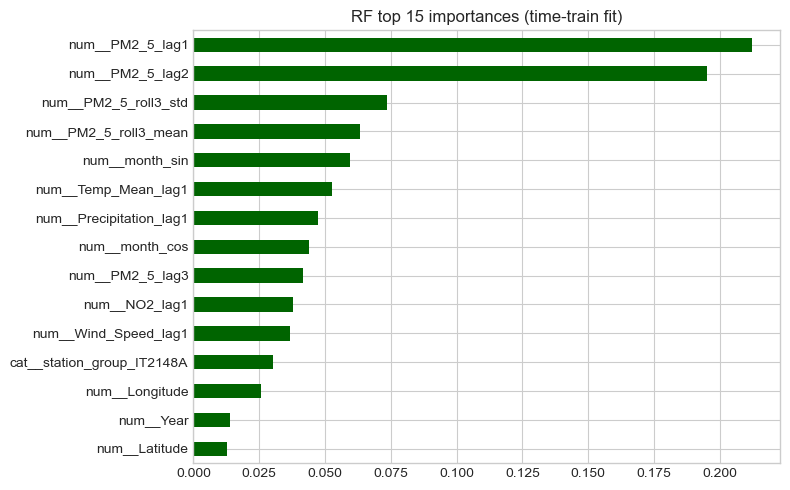

In [16]:
names = rf.named_steps["preprocess"].get_feature_names_out()
imp = pd.Series(rf.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
imp.sort_values().plot(kind="barh", color="darkgreen")
plt.title("RF top 15 importances (time-train fit)")
plt.tight_layout()
plt.show()


### Save time-test predictions (RF)


In [17]:
pred_time = df.loc[time_test_mask, ["date", "PM2_5"]].copy()
if "openaq_id" in df.columns:
    pred_time["openaq_id"] = df.loc[time_test_mask, "openaq_id"].values
pred_time["pred_rf"] = pred_rf_t
pred_time["split"] = "time"

pred_time.to_csv(PRED_OUT, index=False)


### Save space-test predictions (RF)

In [18]:
pred_spatial = df.iloc[te_idx][["date", "PM2_5"]].copy()
if "openaq_id" in df.columns:
    pred_spatial["openaq_id"] = df.iloc[te_idx]["openaq_id"].values
pred_spatial["pred_rf"] = pred_rf_s
pred_spatial["split"] = "spatial"

spatial_path = PRED_OUT.parent / "part3_predictions_spatial.csv"
pred_spatial.to_csv(spatial_path, index=False)

### SHAP


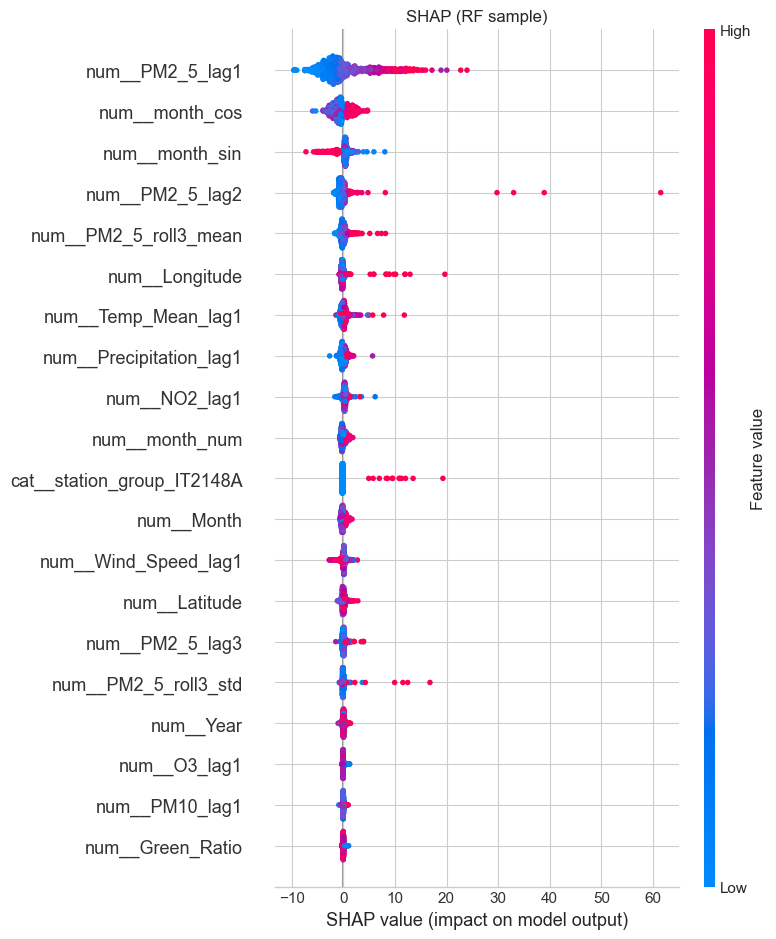

In [19]:
try:
    import scipy.sparse as sp
    import shap
    rf_full = Pipeline([
        ("preprocess", clone(pre)),
        ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ])
    rf_full.fit(X, y)
    Xp = rf_full.named_steps["preprocess"].transform(X)
    if sp.issparse(Xp):
        Xp = Xp.toarray()
    Xp = np.asarray(Xp, dtype=np.float64)
    rng = np.random.RandomState(42)
    n = min(800, Xp.shape[0])
    idx = rng.choice(Xp.shape[0], size=n, replace=False)
    Xs = Xp[idx]
    explainer = shap.TreeExplainer(rf_full.named_steps["model"])
    sv = explainer.shap_values(Xs)
    fn = rf_full.named_steps["preprocess"].get_feature_names_out()
    shap.summary_plot(sv, Xs, feature_names=fn, show=False)
    plt.title("SHAP (RF sample)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("SHAP skipped:", e)


### Handoff checklist

- Metrics + predictions saved.
- Champion printed from **avg RMSE** rule.
- Export plots for slides if needed.

Next: **`week4_policy_translation.ipynb`**.
